# One lane of a quad

A flight controller sees a motor as one verb: rpm, now. This is that
lane - `motion.velocity`, the drive commutating itself sensorless at
50 kHz, thrust as a propeller law fed back to the plant - flown through
arm, hover, a climb step, a descent, disarm. The other three lanes are
unit ids on the same wire; the mixer is four of this block.

What the link prices: the thrust COMMAND updates at tens of hertz, which
is where flight controllers live anyway - the rate loop this lane cannot
close is the drive's own current loop, and that already runs at 50 kHz.

In [1]:
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

root = Path.cwd()
while not (root / 'host' / 'coaxial').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'host'))

from coaxial import Coaxial63100

SIMULATED = True                    # False at the bench
PORT = 'COM4'

rig = Coaxial63100(port=PORT, simulated_device=SIMULATED,
                   power_afe=False).open()
rig.drive.source('model')           # the virtual rotor; 'adc' at the bench
rig.gates.arm(bypass_sto=True, ignore_interlock=True)
print(rig)
BLUE, RED, GREY = '#1f4e79', '#c0392b', '#95a5a6'
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.15})


<Coaxial63100 Simulated SIMULATED>


In [2]:
K_PROP = 1.1e-6           # N m s^2 - the propeller law T = K w^2

log = []
t0 = time.perf_counter()


def fly(v):
    w = v.bus.w
    rig.drive.model_param(load=K_PROP * w * abs(w))   # the air pushes back
    log.append((time.perf_counter() - t0,
                v.bus.w_ref * 60 / (2 * math.pi),
                v.bus.w * 60 / (2 * math.pi), v.bus.iq_ref))


with rig.motion.velocity(amps=4.5, hz=2.5, load_k=K_PROP) as esc:
    esc.rpm(2400, seconds=2.5, watch=fly)     # spool to hover
    esc.rpm(3100, seconds=1.5, watch=fly)     # climb step
    esc.rpm(1700, seconds=1.5, watch=fly)     # descent
    esc.rpm(2400, seconds=1.5, watch=fly)     # back to hover
    esc.stop(2.5)
print('landed at %.0f rpm' % esc.rpm_now)

landed at -54 rpm


hover: 1.4 A for 0.069 N m of prop torque


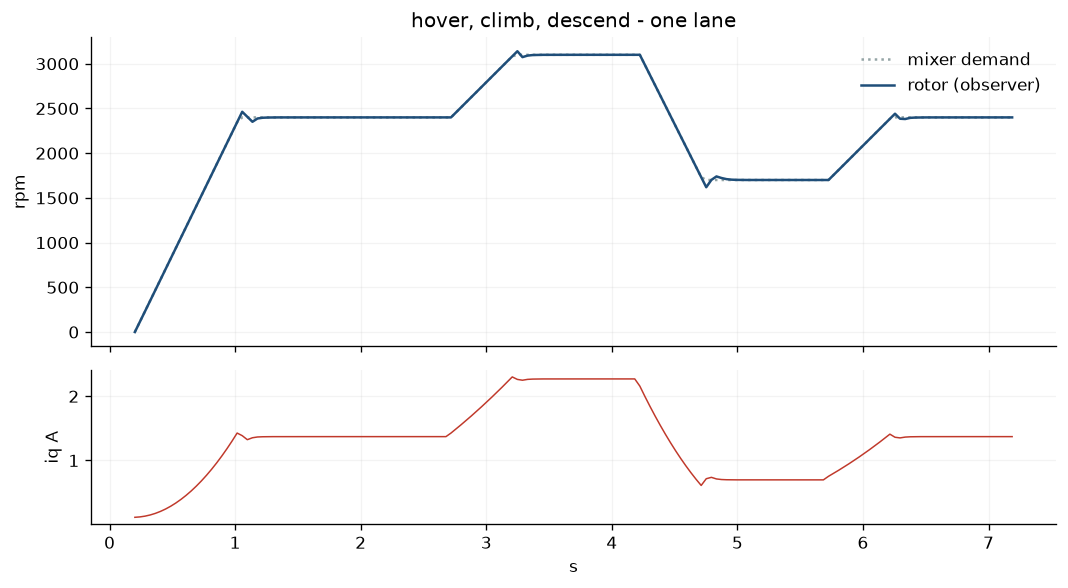

In [3]:
t_s, ref, rpm, iq = np.array(log).T
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(9, 5),
                       gridspec_kw={'height_ratios': [2, 1]})
ax[0].plot(t_s, ref, color=GREY, ls=':', label='mixer demand')
ax[0].plot(t_s, rpm, color=BLUE, label='rotor (observer)')
ax[0].set(ylabel='rpm', title='hover, climb, descend - one lane')
ax[0].legend(frameon=False)
ax[1].plot(t_s, iq, color=RED, lw=0.9)
ax[1].set(xlabel='s', ylabel='iq A')
fig.tight_layout()
thrust = K_PROP * (rpm * 2 * math.pi / 60) ** 2
print('hover: %.1f A for %.3f N m of prop torque' % (
    iq[np.abs(t_s - 2.0) < 0.3].mean(),
    thrust[np.abs(t_s - 2.0) < 0.3].mean()))

## The bench day

The same block against a real propeller: `K_PROP` comes from the prop's
own thrust stand (`coaxial.motor.APC20x10E` carries Hobbywing's), the
amps ceiling from the tune the auto-commissioning wrote, and the step
response above becomes a measurement instead of a model. What a quad
adds beyond this lane - mixing, rate loops, failsafes - lives in the
flight controller; this board's contract is the verb.